In [1]:
# ── Cell 1 — Libraries ────────────────────────────────────────────────
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import pickle
import mlflow
import mlflow.xgboost
import mlflow.lightgbm
import optuna
from optuna.samplers import TPESampler
import warnings
warnings.filterwarnings('ignore')
optuna.logging.set_verbosity(optuna.logging.WARNING)

from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from xgboost import XGBRegressor
from lightgbm import LGBMRegressor

print("Libraries loaded!")

Libraries loaded!


In [2]:
# ── Cell 2 — Load Data ────────────────────────────────────────────────
ts_df = pd.read_csv(
    r'F:\projectss\personal\blinkit_project\data\processed\ts_features.csv'
)
ts_df['datetime'] = pd.to_datetime(ts_df['datetime'])

FEATURES = [
    'hour_sin', 'hour_cos',
    'dow_sin',  'dow_cos',
    'week_sin', 'week_cos',
    'month',
    'lag_1', 'lag_24', 'lag_48', 'lag_168',
    'rolling_mean_24', 'rolling_mean_168', 'rolling_mean_720',
    'rolling_std_24',  'rolling_std_168',
    'rolling_max_24',  'rolling_max_168',
    'ewma_24',         'ewma_168',
    'temperature', 'rainfall', 'humidity',
    'is_raining',  'is_hot',   'is_cold',  'is_humid',
    'is_festival', 'is_weekend',
    'is_peak_hour','is_night',  'is_morning',
]

TARGET   = 'demand_log'
model_df = ts_df.dropna(subset=FEATURES + [TARGET]).copy()

print(f"Total rows : {len(model_df):,}")
print(f"Features   : {len(FEATURES)}")

Total rows : 1,975,538
Features   : 32


In [3]:
# ── Cell 3 — Time Series Split ────────────────────────────────────────
week_max = model_df['week_number'].max()

train = model_df[model_df['week_number'] <= week_max - 4]
val   = model_df[(model_df['week_number'] >  week_max - 4) &
                 (model_df['week_number'] <= week_max - 2)]
test  = model_df[model_df['week_number'] >  week_max - 2]

X_train = train[FEATURES]
y_train = train[TARGET]
X_val   = val[FEATURES]
y_val   = val[TARGET]
X_test  = test[FEATURES]
y_test  = test[TARGET]

print(f"Train : {len(train):,} rows  weeks 1  → {week_max-4}")
print(f"Val   : {len(val):,}  rows  weeks {week_max-3} → {week_max-2}")
print(f"Test  : {len(test):,}  rows  weeks {week_max-1} → {week_max}")

Train : 1,658,686 rows  weeks 1  → 22
Val   : 158,426  rows  weeks 23 → 24
Test  : 158,426  rows  weeks 25 → 26


In [4]:
# ── Cell 4 — Evaluate Function ────────────────────────────────────────
def evaluate(y_true, y_pred, label=''):
    y_true_real = np.expm1(y_true)
    y_pred_real = np.maximum(np.expm1(y_pred), 0)

    mae  = mean_absolute_error(y_true_real,        y_pred_real)
    rmse = np.sqrt(mean_squared_error(y_true_real, y_pred_real))
    r2   = r2_score(y_true_real,                   y_pred_real)

    if label:
        print(f"  {label} → MAE: {mae:.2f} | RMSE: {rmse:.2f} | R2: {r2:.4f}")

    return mae, rmse, r2

print("Evaluate function ready!")

Evaluate function ready!


In [5]:
# ── Cell 5 — MLflow Setup ─────────────────────────────────────────────
MLFLOW_URI = 'file:///F:/projectss/personal/blinkit_project/mlruns'
EXPERIMENT = "blinkit-demand-forecasting"

mlflow.set_tracking_uri(MLFLOW_URI)
mlflow.set_experiment(EXPERIMENT)

print(f"MLflow tracking uri : {MLFLOW_URI}")
print(f"Experiment          : {EXPERIMENT}")
print("✅ MLflow setup done!")

MLflow tracking uri : file:///F:/projectss/personal/blinkit_project/mlruns
Experiment          : blinkit-demand-forecasting
✅ MLflow setup done!


In [6]:
import xgboost as xgb

# check which device is actually being used
model = xgb.XGBRegressor(device='cuda:1')
print(model.get_params()['device'])

# nvidia-smi will show GPU activity
import subprocess
print(subprocess.run(['nvidia-smi'], 
      capture_output=True, text=True).stdout)

cuda:1
Sun Jun 21 21:43:05 2026       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 592.00                 Driver Version: 592.00         CUDA Version: 13.1     |
+-----------------------------------------+------------------------+----------------------+
| GPU  Name                  Driver-Model | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  NVIDIA GeForce GTX 1650 Ti   WDDM  |   00000000:01:00.0 Off |                  N/A |
| N/A   54C    P0             15W /   50W |       0MiB /   4096MiB |      0%      Default |
|                                         |                        |                  N/A |
+----------------------------------------

In [7]:
# ── Cell 6 — Optuna XGBoost Tuning (GPU) ─────────────────────────────
def xgb_objective(trial):
    params = {
        'n_estimators'    : trial.suggest_int('n_estimators', 100, 800),
        'learning_rate'   : trial.suggest_float('learning_rate', 0.01, 0.3, log=True),
        'max_depth'       : trial.suggest_int('max_depth', 3, 10),
        'subsample'       : trial.suggest_float('subsample', 0.5, 1.0),
        'colsample_bytree': trial.suggest_float('colsample_bytree', 0.5, 1.0),
        'min_child_weight': trial.suggest_int('min_child_weight', 1, 20),
        'reg_alpha'       : trial.suggest_float('reg_alpha', 1e-8, 10.0, log=True),
        'reg_lambda'      : trial.suggest_float('reg_lambda', 1e-8, 10.0, log=True),
    }

    model = XGBRegressor(
        **params,
        device       = 'cuda:0',   # ← GPU
        random_state = 42,
        verbosity    = 0,
    )

    model.fit(
        X_train, y_train,
        eval_set = [(X_val, y_val)],
        verbose  = False,
    )

    y_pred        = model.predict(X_val)
    mae, rmse, r2 = evaluate(y_val, y_pred)

    with mlflow.start_run(run_name=f"xgb_trial_{trial.number}", nested=True):
        mlflow.log_params(params)
        mlflow.log_metric("val_mae",  mae)
        mlflow.log_metric("val_rmse", rmse)
        mlflow.log_metric("val_r2",   r2)

    return r2


print("Starting XGBoost Optuna tuning — 50 trials on GPU...")

with mlflow.start_run(run_name="xgb_optuna_study_gpu"):
    xgb_study = optuna.create_study(
        direction = 'maximize',
        sampler   = TPESampler(seed=42)
    )
    xgb_study.optimize(xgb_objective, n_trials=50, show_progress_bar=True)

print(f"\n✅ XGBoost GPU Tuning Complete!")
print(f"Best R2     : {xgb_study.best_value:.4f}")
print(f"Best Params :")
for k, v in xgb_study.best_params.items():
    print(f"  {k:25s} : {v}")

Starting XGBoost Optuna tuning — 50 trials on GPU...


  0%|          | 0/50 [00:00<?, ?it/s]


✅ XGBoost GPU Tuning Complete!
Best R2     : 0.9841
Best Params :
  n_estimators              : 339
  learning_rate             : 0.012770061211771513
  max_depth                 : 9
  subsample                 : 0.5756022545934555
  colsample_bytree          : 0.8611472869134349
  min_child_weight          : 14
  reg_alpha                 : 2.0076267272257486
  reg_lambda                : 0.06499495387027071


In [8]:
# ── Cell 7 — Optuna LightGBM Tuning (GPU) ────────────────────────────
def lgbm_objective(trial):
    params = {
        'n_estimators'     : trial.suggest_int('n_estimators', 100, 800),
        'learning_rate'    : trial.suggest_float('learning_rate', 0.01, 0.3, log=True),
        'max_depth'        : trial.suggest_int('max_depth', 3, 12),
        'num_leaves'       : trial.suggest_int('num_leaves', 20, 200),
        'subsample'        : trial.suggest_float('subsample', 0.5, 1.0),
        'colsample_bytree' : trial.suggest_float('colsample_bytree', 0.5, 1.0),
        'min_child_samples': trial.suggest_int('min_child_samples', 5, 100),
        'reg_alpha'        : trial.suggest_float('reg_alpha', 1e-8, 10.0, log=True),
        'reg_lambda'       : trial.suggest_float('reg_lambda', 1e-8, 10.0, log=True),
    }

    model = LGBMRegressor(
        **params,
        device       = 'gpu',    # ← NVIDIA GTX 1650 Ti
        gpu_device_id= 0,
        random_state = 42,
        verbosity    = -1,
    )

    model.fit(
        X_train, y_train,
        eval_set = [(X_val, y_val)],
    )

    y_pred        = model.predict(X_val)
    mae, rmse, r2 = evaluate(y_val, y_pred)

    with mlflow.start_run(run_name=f"lgbm_trial_{trial.number}", nested=True):
        mlflow.log_params(params)
        mlflow.log_metric("val_mae",  mae)
        mlflow.log_metric("val_rmse", rmse)
        mlflow.log_metric("val_r2",   r2)

    return r2


print("Starting LightGBM Optuna tuning — 50 trials on GTX 1650 Ti...")

with mlflow.start_run(run_name="lgbm_optuna_study"):
    lgbm_study = optuna.create_study(
        direction = 'maximize',
        sampler   = TPESampler(seed=42)
    )
    lgbm_study.optimize(lgbm_objective, n_trials=50, show_progress_bar=True)

print(f"\n✅ LightGBM GPU Tuning Complete!")
print(f"Best R2     : {lgbm_study.best_value:.4f}")
print(f"Best Params :")
for k, v in lgbm_study.best_params.items():
    print(f"  {k:25s} : {v}")

Starting LightGBM Optuna tuning — 50 trials on GTX 1650 Ti...


  0%|          | 0/50 [00:00<?, ?it/s]


✅ LightGBM GPU Tuning Complete!
Best R2     : 0.9824
Best Params :
  n_estimators              : 490
  learning_rate             : 0.012271449547645327
  max_depth                 : 9
  num_leaves                : 186
  subsample                 : 0.959534053117081
  colsample_bytree          : 0.8228969686032476
  min_child_samples         : 73
  reg_alpha                 : 0.021756237813027775
  reg_lambda                : 1.3375563453708794


In [9]:
# ── Cell 8 — Compare Both Studies ────────────────────────────────────
print("="*50)
print("TUNING RESULTS COMPARISON")
print("="*50)
print(f"XGBoost  best R2 : {xgb_study.best_value:.4f}")
print(f"LightGBM best R2 : {lgbm_study.best_value:.4f}")

if xgb_study.best_value >= lgbm_study.best_value:
    print("\n🏆 XGBoost wins!")
    best_model_name   = "XGBoost"
    best_study_params = xgb_study.best_params
else:
    print("\n🏆 LightGBM wins!")
    best_model_name   = "LightGBM"
    best_study_params = lgbm_study.best_params

print(f"\nWinner      : {best_model_name}")
print(f"Best Params : {best_study_params}")

TUNING RESULTS COMPARISON
XGBoost  best R2 : 0.9841
LightGBM best R2 : 0.9824

🏆 XGBoost wins!

Winner      : XGBoost
Best Params : {'n_estimators': 339, 'learning_rate': 0.012770061211771513, 'max_depth': 9, 'subsample': 0.5756022545934555, 'colsample_bytree': 0.8611472869134349, 'min_child_weight': 14, 'reg_alpha': 2.0076267272257486, 'reg_lambda': 0.06499495387027071}


In [10]:
# ── Cell 9 — Train Final Model on Train+Val ───────────────────────────
X_trainval = pd.concat([X_train, X_val])
y_trainval = pd.concat([y_train, y_val])

if best_model_name == "XGBoost":
    final_model = XGBRegressor(
        **best_study_params,
        device       = 'cuda',   # ← GTX 1650 Ti
        random_state = 42,
        verbosity    = 0,
    )
else:
    final_model = LGBMRegressor(
        **best_study_params,
        device       = 'gpu',    # ← GTX 1650 Ti
        gpu_device_id= 0,
        random_state = 42,
        verbosity    = -1,
    )

final_model.fit(X_trainval, y_trainval)

y_pred        = final_model.predict(X_test)
mae, rmse, r2 = evaluate(y_test, y_pred)

print("="*50)
print(f"FINAL MODEL : {best_model_name} on GTX 1650 Ti")
print("="*50)
print(f"Test MAE    : {mae:.2f}")
print(f"Test RMSE   : {rmse:.2f}")
print(f"Test R2     : {r2:.4f}")
print("="*50)

FINAL MODEL : XGBoost on GTX 1650 Ti
Test MAE    : 59.76
Test RMSE   : 121.26
Test R2     : 0.9806


In [11]:
# ── Cell 10 — Log Final Model to MLflow ──────────────────────────────
with mlflow.start_run(run_name=f"FINAL_{best_model_name}_GPU"):
    mlflow.log_param("model_name",  best_model_name)
    mlflow.log_param("gpu",         "NVIDIA GTX 1650 Ti")
    mlflow.log_param("n_features",  len(FEATURES))
    mlflow.log_param("train_rows",  len(X_trainval))
    mlflow.log_param("test_rows",   len(X_test))
    mlflow.log_params(best_study_params)
    mlflow.log_metric("test_mae",   mae)
    mlflow.log_metric("test_rmse",  rmse)
    mlflow.log_metric("test_r2",    r2)

    if best_model_name == "XGBoost":
        mlflow.xgboost.log_model(final_model, "model")
    else:
        mlflow.lightgbm.log_model(final_model, "model")

    print(f"✅ Final {best_model_name} logged to MLflow!")

✅ Final XGBoost logged to MLflow!


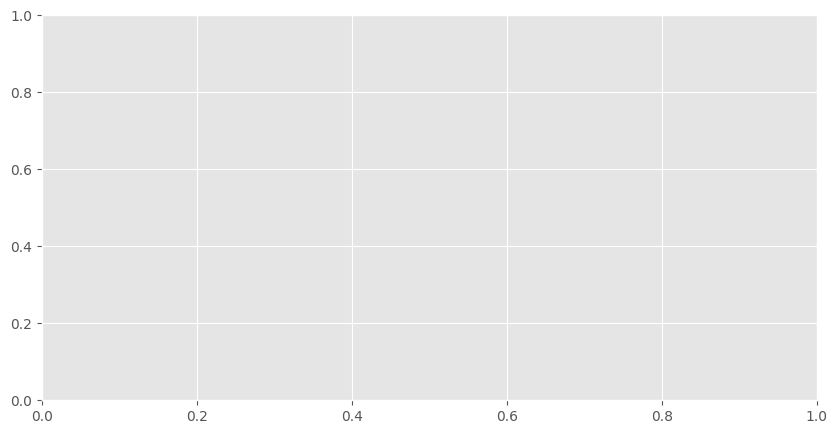

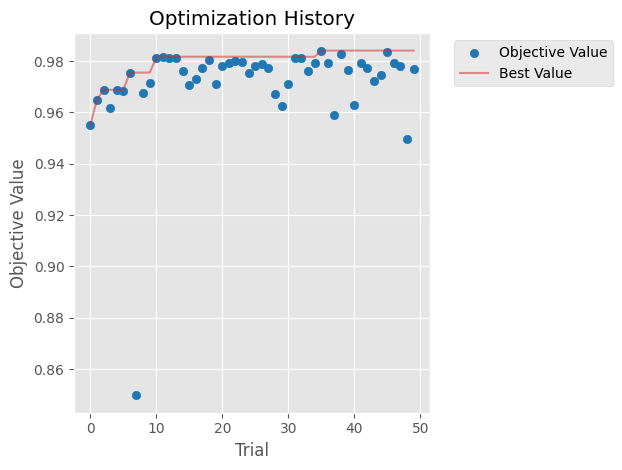

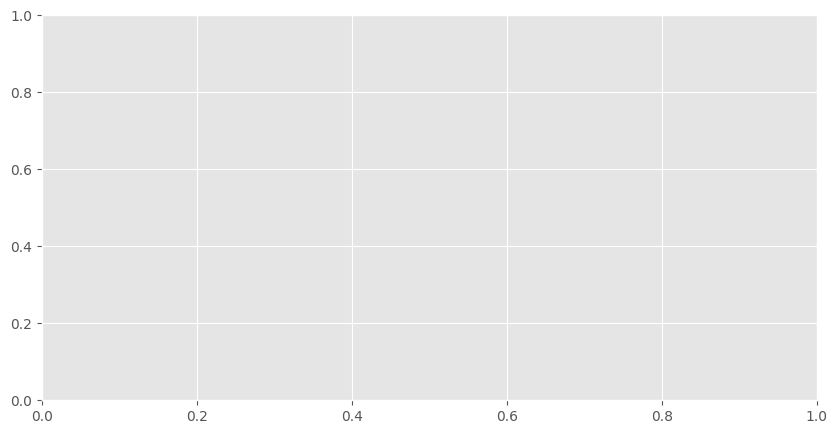

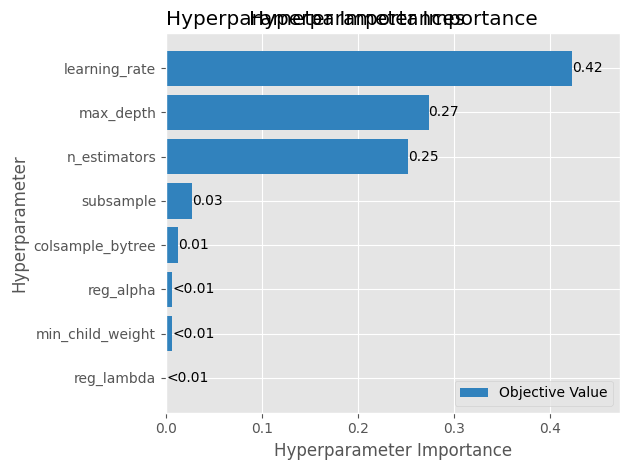

✅ Graphs saved!


In [14]:
# ── Cell 11 — Optuna Visualization (Fixed) ───────────────────────────
import optuna.visualization.matplotlib as optuna_viz

study = xgb_study if best_model_name == "XGBoost" else lgbm_study

# Plot 1 — Optimization History
fig1, ax1 = plt.subplots(figsize=(10, 5))
optuna_viz.plot_optimization_history(study)
plt.title("Optimization History")
plt.tight_layout()
plt.savefig(
    r'F:\projectss\personal\blinkit_project\noteboook\graph\optuna_history.png',
    dpi=150
)
plt.show()

# Plot 2 — Hyperparameter Importance
fig2, ax2 = plt.subplots(figsize=(10, 5))
optuna_viz.plot_param_importances(study)
plt.title("Hyperparameter Importance")
plt.tight_layout()
plt.savefig(
    r'F:\projectss\personal\blinkit_project\noteboook\graph\optuna_importance.png',
    dpi=150
)
plt.show()

print("✅ Graphs saved!")

In [21]:
!pip install kaleido

In [26]:
import plotly.io as pio
print(pio.kaleido.scope.mathjax)
print("✅ Kaleido working!")

AttributeError: 'NoneType' object has no attribute 'mathjax'

In [ ]:
# ── Cell 11 — Optuna Visualization (No Save) ─────────────────────────
from optuna.visualization import (
    plot_optimization_history,
    plot_param_importances,
)

study = xgb_study if best_model_name == "XGBoost" else lgbm_study

# Plot 1 — Optimization History
fig1 = plot_optimization_history(study)
fig1.update_layout(title="XGBoost Optimization History")
fig1.show()

# Plot 2 — Hyperparameter Importance
fig2 = plot_param_importances(study)
fig2.update_layout(title="XGBoost Hyperparameter Importance")
fig2.show()

print("✅ Graphs displayed!")

✅ Graphs displayed!


In [27]:
# ── Cell 11 — Save as HTML ────────────────────────────────────────────
from optuna.visualization import (
    plot_optimization_history,
    plot_param_importances,
)
import os

os.makedirs(
    r'F:\projectss\personal\blinkit_project\noteboook\graph',
    exist_ok=True
)

study = xgb_study if best_model_name == "XGBoost" else lgbm_study

# Plot 1
fig1 = plot_optimization_history(study)
fig1.update_layout(title="XGBoost Optimization History")
fig1.write_html(
    r'F:\projectss\personal\blinkit_project\noteboook\graph\optuna_history.html'
)
fig1.show()

# Plot 2
fig2 = plot_param_importances(study)
fig2.update_layout(title="XGBoost Hyperparameter Importance")
fig2.write_html(
    r'F:\projectss\personal\blinkit_project\noteboook\graph\optuna_importance.html'
)
fig2.show()

print("✅ Graphs saved as HTML!")

✅ Graphs saved as HTML!
